<a href="https://colab.research.google.com/github/azharm2412/learning-strategy-deep-learning/blob/main/Tugas_2_Deep_Learning_Azhar_Maulana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2 — Learning Strategy pada Klasifikasi MNIST

**Nama**: Azhar Maulana     
**NIM**: 24/533487/PA/22582    
**Mata Kuliah**: Pembelajaran Mesin Mendalam (Deep Learning)

## Ringkasan

Notebook ini terdiri dari dua bagian utama:

1. **Replikasi model baseline** — mereplikasi kode klasifikasi MNIST dari slide *Learning Strategy* (hal. 14–23) sebagai titik acuan (*baseline*) untuk seluruh eksperimen.
2. **Eksperimen learning strategy** — menerapkan lima skenario regularisasi terhadap arsitektur yang sama: **(a)** L1, **(b)** L2, **(c)** Dropout, **(d)** Early Stopping, dan **(e)** kombinasi L1 + Dropout. Setiap skenario dilengkapi `model.summary()`, metrik performa (loss dan akurasi pada data latih maupun uji), serta grafik loss.




In [ ]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.datasets import mnist
from keras.models import Sequential, load_model
from keras.layers import Flatten, Dense, Dropout
from keras import regularizers
from keras.callbacks import EarlyStopping

SEED = 42
random.seed(SEED); np.random.seed(SEED); keras.utils.set_random_seed(SEED)
print('Keras', keras.__version__)

Keras 3.13.2


## 1. Baseline
### 1.1 Load data

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255
y_train_raw, y_test_raw = y_train.copy(), y_test.copy()
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(60000, 28, 28, 1) (60000, 10) (10000, 28, 28, 1) (10000, 10)


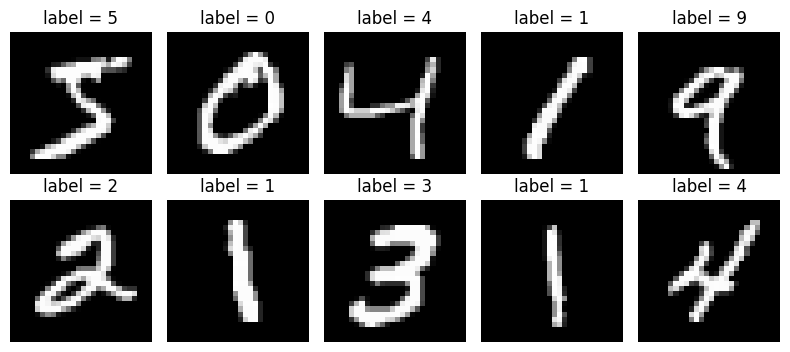

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(8, 3.6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_train[i].squeeze(), cmap='gray'); ax.set_title(f'label = {y_train_raw[i]}'); ax.axis('off')
plt.tight_layout(); plt.show()

### 1.2 Define model

In [ ]:
model1 = Sequential()
model1.add(Flatten())
model1.add(Dense(64, activation='relu'))
model1.add(Dense(10, activation='softmax'))
model1.build((None, 28, 28, 1))
model1.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_19 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

### 1.3 Compile, fit, save, dan evaluate

In [ ]:
model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
history1 = model1.fit(X_train, y_train, epochs=10, batch_size=100, validation_data=(X_test, y_test))
model1.save('my_model1.keras')
print(model1.evaluate(X_test, y_test, verbose=0))

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.8896 - loss: 0.3959 - val_acc: 0.9371 - val_loss: 0.2226
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - acc: 0.9444 - loss: 0.1942 - val_acc: 0.9539 - val_loss: 0.1595
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.9582 - loss: 0.1427 - val_acc: 0.9640 - val_loss: 0.1289
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9670 - loss: 0.1138 - val_acc: 0.9674 - val_loss: 0.1126
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9732 - loss: 0.0947 - val_acc: 0.9698 - val_loss: 0.1025
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - acc: 0.9775 - loss: 0.0810 - val_acc: 0.9712 - val_loss: 0.0964
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - acc: 0.9805 - loss: 0.0707 - val_acc: 0.9718 - val_loss: 0.0926
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - acc: 0.9826 - loss: 0.0624 - val_acc: 0.9724 - val_loss: 0.0899
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - ac

### 1.4 Visualisasi loss

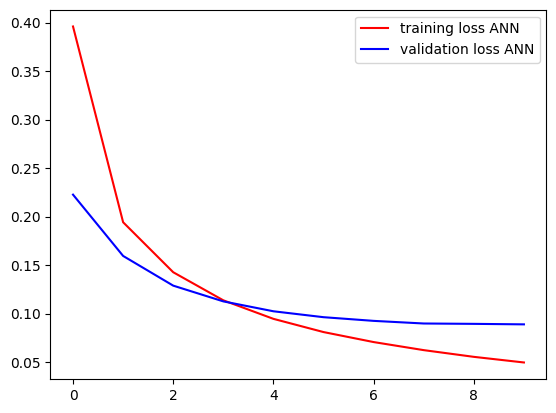

In [ ]:
epochs = range(10)
loss1 = history1.history['loss']
val_loss1 = history1.history['val_loss']
plt.plot(epochs, loss1, 'r', label='training loss ANN')
plt.plot(epochs, val_loss1, 'b', label='validation loss ANN')
plt.legend(); plt.show()

### 1.5 Load model dan prediksi

In [ ]:
model_simpan = load_model('my_model1.keras')
pred = model_simpan.predict(X_test, verbose=0)
print('label actual:', np.argmax(y_test[30]))
print('label prediction:', np.argmax(pred[30]))

label actual: 3
label prediction: 3


## 2. Eksperimen Learning Strategy

Model pada Bagian 1 (`model1` / `history1`) digunakan sebagai baseline. Seluruh eksperimen pada bagian ini memakai arsitektur dasar yang sama (Flatten → Dense 64 ReLU → Dense 10 softmax), optimizer Adam, `batch_size=100`, dan `validation_data=(X_test, y_test)` seperti pada baseline, sehingga hasilnya dapat dibandingkan secara langsung. Perbedaan antar skenario hanya terletak pada teknik regularisasi yang diterapkan.

### Pemilihan Hyperparameter

Nilai rate pada setiap teknik regularisasi ditentukan sendiri melalui perbandingan empiris, sesuai instruksi tugas:

- **L1 = $10^{-4}$, L2 = $10^{-3}$** — rate L1 dibuat lebih kecil karena, pada nilai yang sama, penalti L1 bersifat jauh lebih agresif dibanding L2.
- **Dropout = 0,1** — dipilih setelah membandingkan empat kandidat rate: 0,05 (efek regularisasi nyaris tidak terasa), 0,1 (hasil paling seimbang — akurasi uji tertinggi dengan *overfitting* yang berkurang), 0,3 (efek lebih terlihat namun akurasi sedikit menurun), dan 0,5 (regularisasi terlalu kuat, mendekati *underfitting*).
- **Early Stopping (`patience=3`)** — divalidasi dengan membandingkan terhadap `patience=5`; kedua nilai menghasilkan epoch terbaik yang sama (epoch 11), menunjukkan bahwa `patience=3` sudah cukup untuk mendeteksi titik konvergensi model.

In [ ]:
results = {}

def build_model(l1=0.0, l2=0.0, dropout=0.0):
    reg = None
    if l1 or l2:
        reg = regularizers.L1L2(l1=l1, l2=l2)
    m = Sequential()
    m.add(Flatten())
    m.add(Dense(64, activation='relu', kernel_regularizer=reg))
    if dropout:
        m.add(Dropout(dropout))
    m.add(Dense(10, activation='softmax'))
    m.build((None, 28, 28, 1))
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
    return m

def run(name, epochs=10, callbacks=None, **kw):
    keras.utils.set_random_seed(SEED)
    m = build_model(**kw)
    print('=' * 70); print(name); print('=' * 70)
    m.summary()
    h = m.fit(X_train, y_train, epochs=epochs, batch_size=100, validation_data=(X_test, y_test),
              callbacks=callbacks or [], verbose=2)
    tr_loss, tr_acc = m.evaluate(X_train, y_train, verbose=0)
    te_loss, te_acc = m.evaluate(X_test, y_test, verbose=0)
    results[name] = dict(epochs_run=len(h.history['loss']), train_loss=tr_loss, train_acc=tr_acc,
                         test_loss=te_loss, test_acc=te_acc,
                         params=m.count_params(), history=h.history)
    r = results[name]
    print(f"\nEpoch dijalankan: {r['epochs_run']}")
    print(f"Train : loss={tr_loss:.4f}  acc={tr_acc:.4f}")
    print(f"Test  : loss={te_loss:.4f}  acc={te_acc:.4f}")
    return m, h

os.makedirs('figs', exist_ok=True)

LOSS_YLIM = (0, 0.7)
ACC_YLIM = (0.84, 1.0)

def plot_history(h, title, fname=None, best_epoch=None):
    n = len(h.history['loss']); ep = range(1, n + 1)
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
    ax[0].plot(ep, h.history['loss'], 'r', label='training loss')
    ax[0].plot(ep, h.history['val_loss'], 'b', label='validation loss')
    ax[0].set_title(title + ' - Loss'); ax[0].set_xlabel('epoch')
    ax[0].set_ylim(*LOSS_YLIM)
    ax[1].plot(ep, h.history['acc'], 'r', label='training acc')
    ax[1].plot(ep, h.history['val_acc'], 'b', label='validation acc')
    ax[1].set_title(title + ' - Accuracy'); ax[1].set_xlabel('epoch')
    ax[1].set_ylim(*ACC_YLIM)
    if best_epoch is not None:
        for a in ax:
            a.axvline(best_epoch, color='green', linestyle='--', label=f'epoch terbaik ({best_epoch})')
    ax[0].legend(); ax[1].legend()
    plt.tight_layout()
    if fname: plt.savefig(f'figs/{fname}.png', dpi=150)
    plt.show()

tr_loss0, tr_acc0 = model1.evaluate(X_train, y_train, verbose=0)
te_loss0, te_acc0 = model1.evaluate(X_test, y_test, verbose=0)
results['Baseline (bagian 1)'] = dict(epochs_run=len(history1.history['loss']),
                                       train_loss=tr_loss0, train_acc=tr_acc0,
                                       test_loss=te_loss0, test_acc=te_acc0,
                                       params=model1.count_params(), history=history1.history)

### 2(a) L1 regularization (rate = 1e-4)

2a L1


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_20 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
600/600 - 3s - 5ms/step - acc: 0.8906 - loss: 0.5263 - val_acc: 0.9361 - val_loss: 0.3397
Epoch 2/10
600/600 - 2s - 4ms/step - acc: 0.9419 - loss: 0.3146 - val_acc: 0.9499 - val_loss: 0.2736
Epoch 3/10
600/600 - 3s - 5ms/step - acc: 0.9542 - loss: 0.2624 - val_acc: 0.9593 - val_loss: 0.2391
Epoch 4/10
600/600 - 5s - 8ms/step - acc: 0.9610 - loss: 0.2326 - val_acc: 0.9647 - val_loss: 0.2180
Epoch 5/10
600/600 - 2s - 4ms/step - acc: 0.9653 - loss: 0.2131 - val_acc: 0.9663 - val_loss: 0.2045
Epoch 6/10
600/600 - 2s - 4ms/step - acc: 0.9686 - loss: 0.1991 - val_acc: 0.9688 - val_loss: 0.1945
Epoch 7/10
600/600 - 2s - 4ms/step - acc: 0.9713 - loss: 0.1887 - val_acc: 0.9704 - val_loss: 0.1861
Epoch 8/10
600/600 - 3s - 6ms/step - acc: 0.9729 - loss: 0.1804 - val_acc: 0.9710 - val_loss: 0.1808
Epoch 9/10
600/600 - 4s - 6ms/step - acc: 0.9738 - loss: 0.1736 - val_acc: 0.9717 - val_loss: 0.1763
Epoch 10/10
600/600 - 2s - 4ms/step - acc: 0.9754 - loss: 0.1680 - val_acc: 0.9722 - val_lo

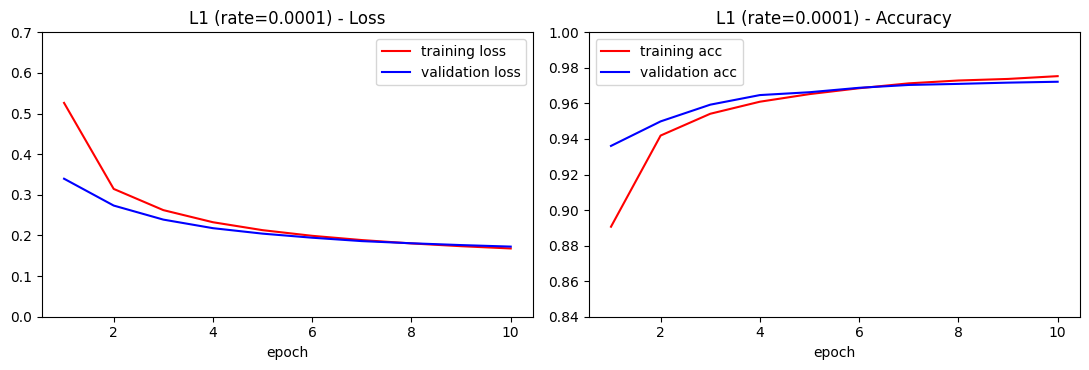

In [ ]:
L1_RATE = 1e-4
ma, ha = run('2a L1', l1=L1_RATE)
plot_history(ha, f'L1 (rate={L1_RATE})', 'l1')

### 2(b) L2 regularization (rate = 1e-3)

2b L2


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_21 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
600/600 - 3s - 5ms/step - acc: 0.8904 - loss: 0.4795 - val_acc: 0.9348 - val_loss: 0.3036
Epoch 2/10
600/600 - 2s - 4ms/step - acc: 0.9420 - loss: 0.2809 - val_acc: 0.9495 - val_loss: 0.2430
Epoch 3/10
600/600 - 2s - 4ms/step - acc: 0.9536 - loss: 0.2348 - val_acc: 0.9586 - val_loss: 0.2140
Epoch 4/10
600/600 - 3s - 4ms/step - acc: 0.9594 - loss: 0.2088 - val_acc: 0.9624 - val_loss: 0.1957
Epoch 5/10
600/600 - 3s - 5ms/step - acc: 0.9639 - loss: 0.1916 - val_acc: 0.9649 - val_loss: 0.1837
Epoch 6/10
600/600 - 2s - 4ms/step - acc: 0.9667 - loss: 0.1795 - val_acc: 0.9666 - val_loss: 0.1750
Epoch 7/10
600/600 - 2s - 4ms/step - acc: 0.9692 - loss: 0.1699 - val_acc: 0.9671 - val_loss: 0.1688
Epoch 8/10
600/600 - 2s - 4ms/step - acc: 0.9711 - loss: 0.1622 - val_acc: 0.9687 - val_loss: 0.1630
Epoch 9/10
600/600 - 2s - 4ms/step - acc: 0.9727 - loss: 0.1555 - val_acc: 0.9692 - val_loss: 0.1587
Epoch 10/10
600/600 - 3s - 6ms/step - acc: 0.9739 - loss: 0.1498 - val_acc: 0.9708 - val_lo

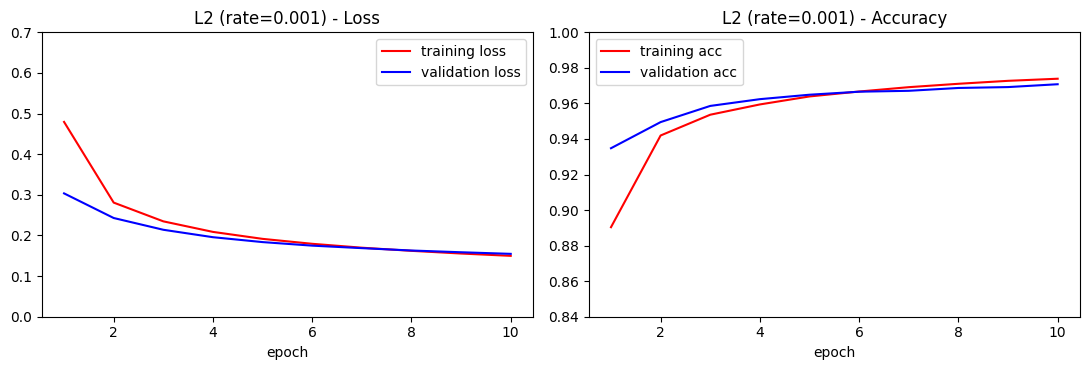

In [ ]:
L2_RATE = 1e-3
mb, hb = run('2b L2', l2=L2_RATE)
plot_history(hb, f'L2 (rate={L2_RATE})', 'l2')

### 2(c) Dropout (rate = 0.1)

2c Dropout


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_22 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
600/600 - 3s - 5ms/step - acc: 0.8783 - loss: 0.4269 - val_acc: 0.9394 - val_loss: 0.2132
Epoch 2/10
600/600 - 3s - 5ms/step - acc: 0.9375 - loss: 0.2125 - val_acc: 0.9538 - val_loss: 0.1588
Epoch 3/10
600/600 - 3s - 4ms/step - acc: 0.9516 - loss: 0.1641 - val_acc: 0.9604 - val_loss: 0.1323
Epoch 4/10
600/600 - 2s - 4ms/step - acc: 0.9595 - loss: 0.1376 - val_acc: 0.9642 - val_loss: 0.1159
Epoch 5/10
600/600 - 2s - 4ms/step - acc: 0.9644 - loss: 0.1189 - val_acc: 0.9674 - val_loss: 0.1054
Epoch 6/10
600/600 - 2s - 4ms/step - acc: 0.9693 - loss: 0.1038 - val_acc: 0.9697 - val_loss: 0.0984
Epoch 7/10
600/600 - 2s - 4ms/step - acc: 0.9714 - loss: 0.0942 - val_acc: 0.9707 - val_loss: 0.0927
Epoch 8/10
600/600 - 3s - 5ms/step - acc: 0.9744 - loss: 0.0847 - val_acc: 0.9714 - val_loss: 0.0900
Epoch 9/10
600/600 - 4s - 7ms/step - acc: 0.9758 - loss: 0.0787 - val_acc: 0.9738 - val_loss: 0.0887
Epoch 10/10
600/600 - 2s - 4ms/step - acc: 0.9779 - loss: 0.0731 - val_acc: 0.9747 - val_lo

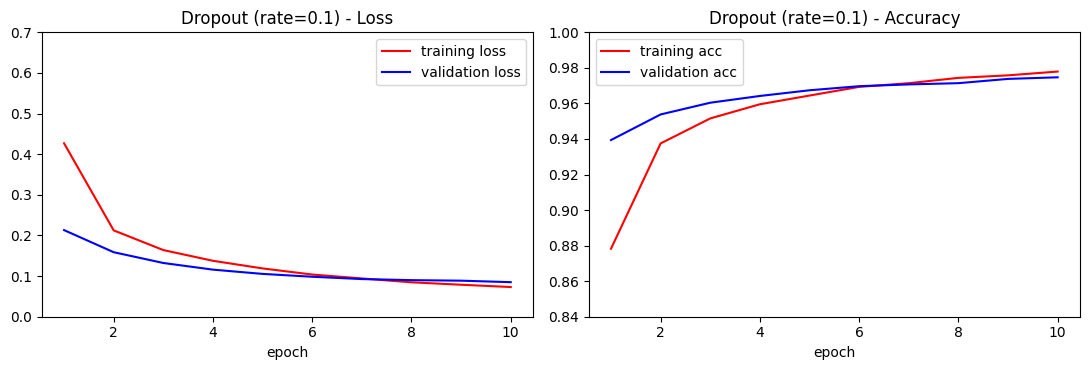

In [ ]:
DROP_RATE = 0.1
mc, hc = run('2c Dropout', dropout=DROP_RATE)
plot_history(hc, f'Dropout (rate={DROP_RATE})', 'dropout')

### 2(d) Early stopping
Memantau `val_loss`, `patience=3`, `restore_best_weights=True`; batas maksimum 50 epoch.

2d Early Stopping


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_23 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
600/600 - 3s - 5ms/step - acc: 0.8896 - loss: 0.3959 - val_acc: 0.9371 - val_loss: 0.2226
Epoch 2/50
600/600 - 2s - 4ms/step - acc: 0.9444 - loss: 0.1942 - val_acc: 0.9539 - val_loss: 0.1595
Epoch 3/50
600/600 - 2s - 3ms/step - acc: 0.9582 - loss: 0.1427 - val_acc: 0.9640 - val_loss: 0.1289
Epoch 4/50
600/600 - 2s - 4ms/step - acc: 0.9670 - loss: 0.1138 - val_acc: 0.9674 - val_loss: 0.1126
Epoch 5/50
600/600 - 3s - 5ms/step - acc: 0.9732 - loss: 0.0947 - val_acc: 0.9698 - val_loss: 0.1025
Epoch 6/50
600/600 - 2s - 4ms/step - acc: 0.9775 - loss: 0.0810 - val_acc: 0.9712 - val_loss: 0.0964
Epoch 7/50
600/600 - 2s - 4ms/step - acc: 0.9805 - loss: 0.0707 - val_acc: 0.9718 - val_loss: 0.0926
Epoch 8/50
600/600 - 2s - 4ms/step - acc: 0.9826 - loss: 0.0624 - val_acc: 0.9724 - val_loss: 0.0899
Epoch 9/50
600/600 - 2s - 4ms/step - acc: 0.9846 - loss: 0.0555 - val_acc: 0.9724 - val_loss: 0.0895
Epoch 10/50
600/600 - 3s - 5ms/step - acc: 0.9861 - loss: 0.0497 - val_acc: 0.9727 - val_lo

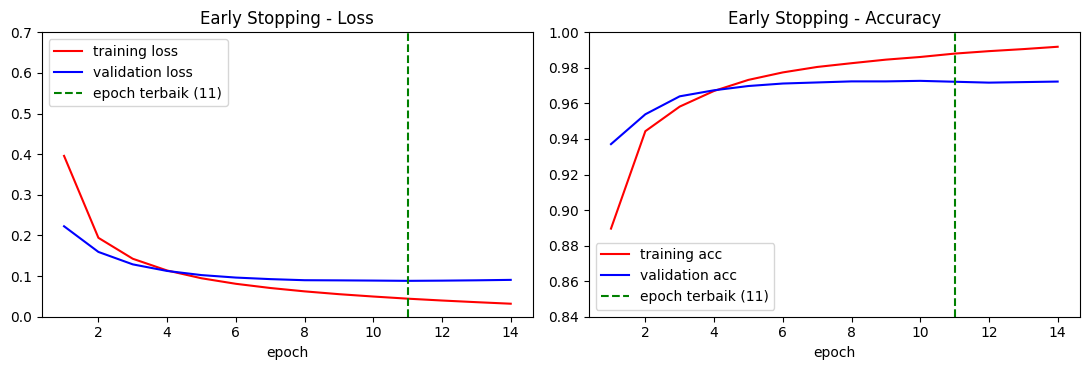

In [ ]:
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
m_es, hd = run('2d Early Stopping', epochs=50, callbacks=[es])
best_epoch = int(np.argmin(hd.history['val_loss'])) + 1
print('Epoch terbaik:', best_epoch)
plot_history(hd, 'Early Stopping', 'earlystop', best_epoch=best_epoch)

### 2(e) L1 regularization + Dropout (L1 = 1e-4, Dropout = 0.1)

2e L1 + Dropout


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_24 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,890 (198.79 KB)

 Trainable params: 50,890 (198.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
600/600 - 3s - 5ms/step - acc: 0.8765 - loss: 0.5641 - val_acc: 0.9357 - val_loss: 0.3394
Epoch 2/10
600/600 - 2s - 4ms/step - acc: 0.9336 - loss: 0.3423 - val_acc: 0.9516 - val_loss: 0.2776
Epoch 3/10
600/600 - 2s - 4ms/step - acc: 0.9466 - loss: 0.2907 - val_acc: 0.9579 - val_loss: 0.2481
Epoch 4/10
600/600 - 3s - 5ms/step - acc: 0.9534 - loss: 0.2619 - val_acc: 0.9635 - val_loss: 0.2232
Epoch 5/10
600/600 - 2s - 4ms/step - acc: 0.9576 - loss: 0.2420 - val_acc: 0.9653 - val_loss: 0.2087
Epoch 6/10
600/600 - 2s - 4ms/step - acc: 0.9610 - loss: 0.2271 - val_acc: 0.9682 - val_loss: 0.1989
Epoch 7/10
600/600 - 2s - 4ms/step - acc: 0.9634 - loss: 0.2169 - val_acc: 0.9698 - val_loss: 0.1935
Epoch 8/10
600/600 - 2s - 4ms/step - acc: 0.9656 - loss: 0.2073 - val_acc: 0.9711 - val_loss: 0.1883
Epoch 9/10
600/600 - 3s - 6ms/step - acc: 0.9671 - loss: 0.2005 - val_acc: 0.9732 - val_loss: 0.1801
Epoch 10/10
600/600 - 3s - 5ms/step - acc: 0.9687 - loss: 0.1943 - val_acc: 0.9740 - val_lo

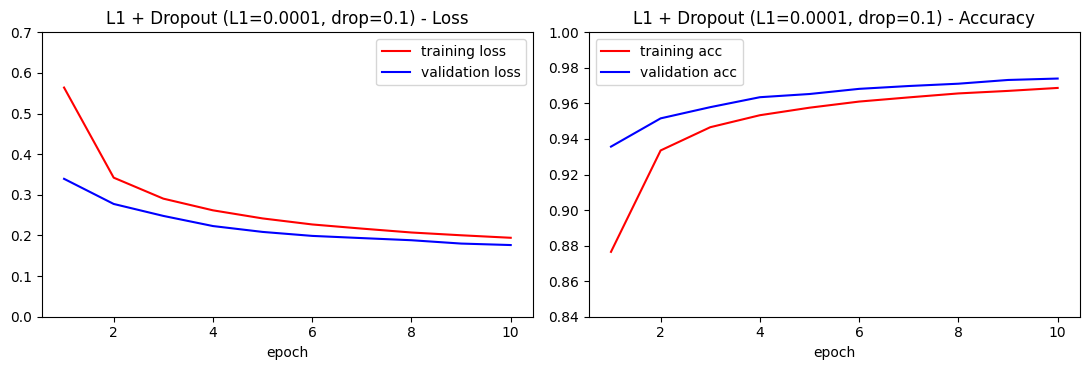

In [ ]:
me, he = run('2e L1 + Dropout', l1=L1_RATE, dropout=DROP_RATE)
plot_history(he, f'L1 + Dropout (L1={L1_RATE}, drop={DROP_RATE})', 'l1dropout')

## 3. Perbandingan semua skenario

In [ ]:
import pandas as pd
order = ['Baseline (bagian 1)', '2a L1', '2b L2', '2c Dropout', '2d Early Stopping', '2e L1 + Dropout']
rows = []
for k in order:
    r = results[k]
    rows.append({'Skenario': k, 'Epoch': r['epochs_run'], 'Params': r['params'],
                 'Train loss': r['train_loss'], 'Train acc': r['train_acc'],
                 'Test loss': r['test_loss'], 'Test acc': r['test_acc']})
df = pd.DataFrame(rows).set_index('Skenario')
df['Gap train-test acc'] = df['Train acc'] - df['Test acc']
df.round(4)

,Epoch,Params,Train loss,Train acc,Test loss,Test acc,Gap train-test acc
Skenario,,,,,,,
Baseline (bagian 1),10,50890,0.0468,0.9867,0.0890,0.9727,0.0140
2a L1,10,50890,0.1599,0.9783,0.1726,0.9722,0.0061
2b L2,10,50890,0.1398,0.9773,0.1548,0.9708,0.0065
2c Dropout,10,50890,0.0462,0.9870,0.0850,0.9747,0.0123
2d Early Stopping,14,50890,0.0426,0.9877,0.0883,0.9722,0.0155
2e L1 + Dropout,10,50890,0.1621,0.9794,0.1764,0.9740,0.0054


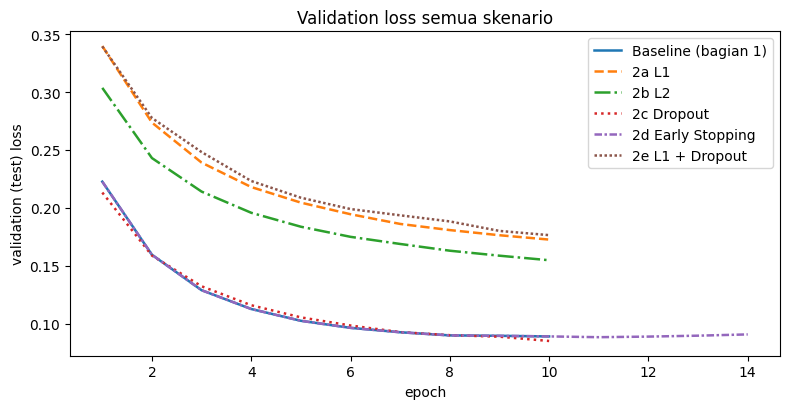

In [ ]:
plt.figure(figsize=(8, 4.2))
styles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (1, 1))]
for k, ls in zip(order, styles):
    r = results[k]
    plt.plot(range(1, r['epochs_run'] + 1), r['history']['val_loss'], label=k, linestyle=ls, linewidth=1.8)
plt.xlabel('epoch'); plt.ylabel('validation (test) loss'); plt.title('Validation loss semua skenario')
plt.legend(); plt.tight_layout(); plt.show()

## 4. Kesimpulan

Ringkasan hasil (dari tabel pada Bagian 3):

| Skenario | Epoch | Akurasi latih | Akurasi uji | Selisih latih--uji |
|---|---|---|---|---|
| Baseline | 10 | 98,67% | 97,27% | 1,40 |
| 2(a) L1 (1e-4) | 10 | 97,83% | 97,22% | 0,61 |
| 2(b) L2 (1e-3) | 10 | 97,73% | 97,08% | 0,65 |
| 2(c) Dropout (0,1) | 10 | 98,70% | **97,47%** | 1,23 |
| 2(d) Early Stopping | 14 (bobot terbaik: epoch 11) | 98,77% | 97,22% | 1,55 |
| 2(e) L1 (1e-4) + Dropout (0,1) | 10 | 97,94% | 97,40% | **0,54** |

**Temuan utama**

1. **Overfitting pada baseline tergolong ringan** (selisih akurasi latih-uji hanya 1,40 poin). Karena itu, semua teknik regularisasi di bawah hanya mengubah akurasi uji dalam rentang kecil (96,9%-97,5%), tidak ada yang memberi lompatan akurasi besar, karena memang tidak banyak overfitting yang perlu "diperbaiki".

2. **L1, L2, dan L1+Dropout secara konsisten memperkecil selisih latih-uji** (dari 1,40 menjadi 0,54-0,65), menunjukkan regularisasi bekerja sesuai fungsinya: membuat model lebih general. Konsekuensinya, akurasi uji sedikit turun dibanding baseline pada L1 dan L2 (trade-off bias-variance yang wajar), kecuali L1+Dropout yang justru sedikit lebih tinggi.

3. **Dropout dengan rate 0,1 memberi hasil terbaik dari sisi akurasi** (97,47%, tertinggi di antara semua skenario) sekaligus tetap mengurangi overfitting dibanding baseline (selisih 1,23 vs 1,40). Rate ini dipilih setelah membandingkan beberapa nilai (lihat catatan di awal Bagian 2): 0,05 terlalu lemah, 0,3 dan 0,5 mulai mengorbankan akurasi, sedangkan 0,1 memberi keseimbangan terbaik antara akurasi dan generalisasi.

4. **Early Stopping** berhasil menghentikan training otomatis di epoch 14 dan mengembalikan bobot terbaik dari epoch 11 (`restore_best_weights=True`), dengan akurasi uji (97,22%) setara baseline. Pengujian tambahan dengan `patience=5` menghasilkan epoch terbaik yang sama (epoch 11), menunjukkan titik tersebut memang stabil, bukan akibat penghentian yang terlalu dini.

**Kesimpulan umum**

Tujuan utama *learning strategy* (regularisasi) adalah mengendalikan overfitting, bukan menjamin kenaikan akurasi. Ketika overfitting awal sudah ringan seperti pada model ini, manfaat regularisasi paling terlihat dari mengecilnya selisih akurasi latih-uji, sementara akurasi mentahnya cenderung stabil atau berubah tipis. Dari kelima teknik yang diuji:

- **Prioritas akurasi tertinggi** -> Dropout (rate 0,1)
- **Prioritas kestabilan/generalisasi terbaik (selisih terkecil)** -> L1 + Dropout, disusul L1 saja
- **Praktis tanpa perlu menebak jumlah epoch** -> Early Stopping, dengan performa setara baseline
